[Config] STAGE   : 1
[Config] Device  : cuda
[Config] Loss    : mse
[Config] K-Folds : 1

── Backbone channel diagnostic ──


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

  Stage 0: shape=(2, 32, 128, 128)  channels=32
  Stage 1: shape=(2, 64, 64, 64)  channels=64
  Stage 2: shape=(2, 96, 32, 32)  channels=96
  Stage 3: shape=(2, 128, 16, 16)  channels=128
  Stage 4: shape=(2, 640, 8, 8)  channels=640

  → Set BACKBONE_CHANNELS = [32, 64, 96, 128, 640]
  → Model uses stages 2,3,4: ch3=96, ch4=128, ch5=640
[JSON] 1000 entries parsed.
[Data] Matched : 1023 images
[Data] MOS     : 0.0 → 88.0

[Mode] Single 80/10/10 stratified split
  Train: 818 samples
  Val  : 102 samples
  Test : 103 samples


[Model] Auto-detected backbone channels: [32, 64, 96, 128, 640]
[Model] Using stages 2,3,4 → ch=96,128,640

  Fold 0 | Phase 1 — backbone frozen
  Total params     : 5,164,833
  Trainable params : 227,201
  [F0-P1] Ep 001/15 | Loss 0.0586/0.0527 | PLCC 0.5248 | SROCC 0.4641 | RMSE 20.21
    ✓ Saved  PLCC=0.5248
  [F0-P1] Ep 002/15 | Loss 0.0456/0.0301 | PLCC 0.6887 | SROCC 0.6693 | RMSE 15.28
    ✓ Saved  PLCC=0.6887
  [F0-P1] Ep 003/15 | Loss 0.0301/0.0241 | PLCC 0.7619 | SROCC 0.7485 | RMSE 13.67
    ✓ Saved  PLCC=0.7619
  [F0-P1] Ep 004/15 | Loss 0.0251/0.0221 | PLCC 0.7801 | SROCC 0.7772 | RMSE 13.08
    ✓ Saved  PLCC=0.7801
  [F0-P1] Ep 005/15 | Loss 0.0212/0.0201 | PLCC 0.7939 | SROCC 0.7858 | RMSE 12.47
    ✓ Saved  PLCC=0.7939
  [F0-P1] Ep 006/15 | Loss 0.0195/0.0190 | PLCC 0.8048 | SROCC 0.8090 | RMSE 12.14
    ✓ Saved  PLCC=0.8048
  [F0-P1] Ep 007/15 | Loss 0.0176/0.0215 | PLCC 0.7985 | SROCC 0.7955 | RMSE 12.91
  [F0-P1] Ep 008/15 | Loss 0.0174/0.0201 | PLCC 0.8009 | SROCC 0

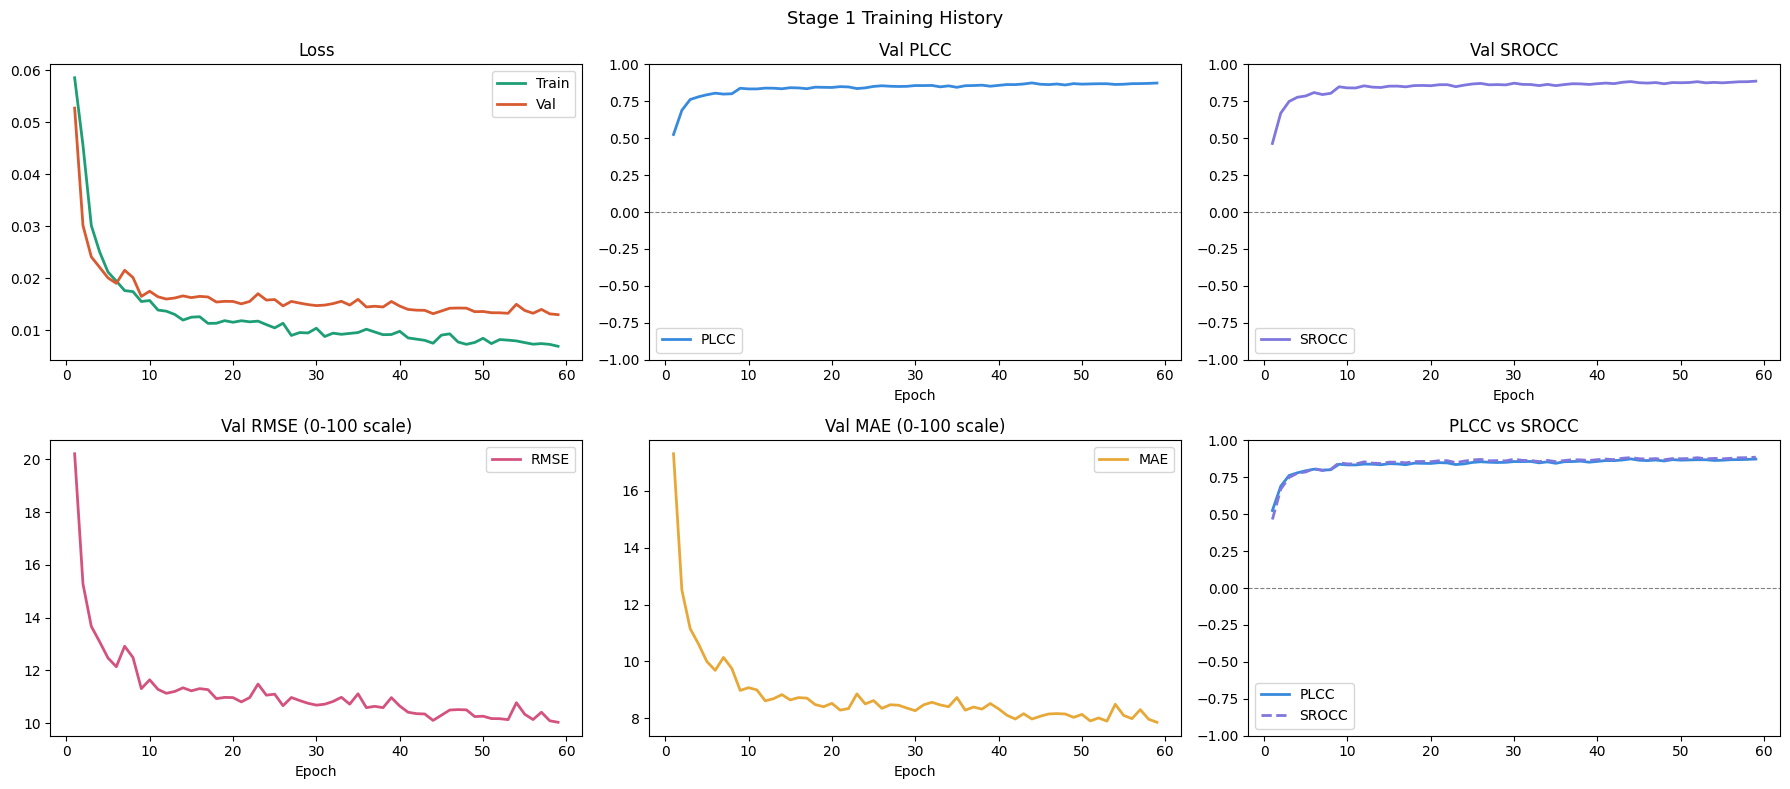

[Saved] stage1_training_curves.png


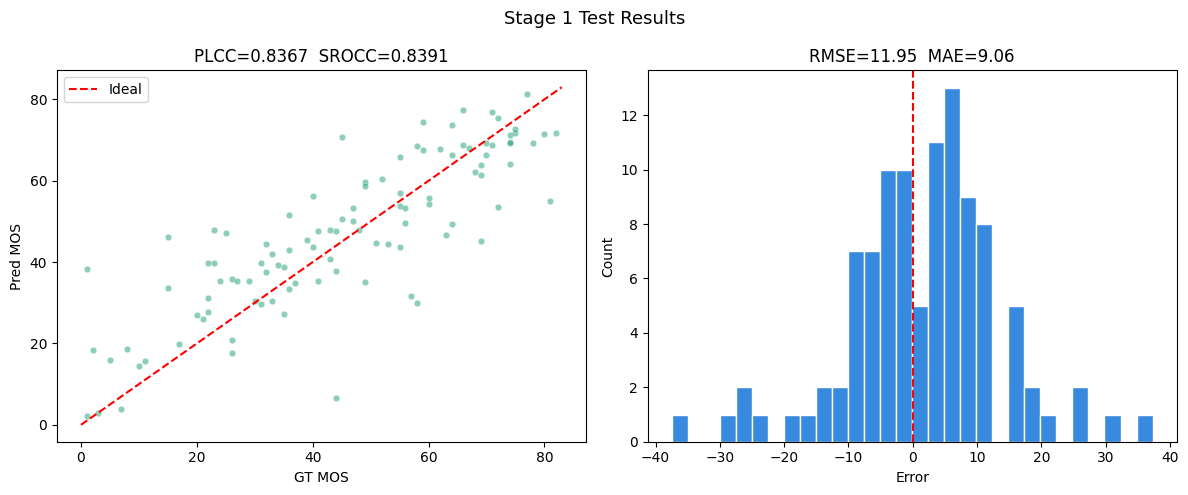

[Saved] stage1_test_results.png


In [ ]:

import os, json, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageFilter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from scipy import stats
from sklearn.model_selection import train_test_split, KFold
import timm

# ─────────────────────────────────────────────────────────────
# 0.  MASTER STAGE SWITCH  ← Change only this number
# ─────────────────────────────────────────────────────────────
#
#  STAGE 1 : Pretrained backbone + MSE loss  (baseline improvement)
#  STAGE 2 : + IQALoss (rank-aware)
#  STAGE 3 : + Mild underwater augmentation
#  STAGE 4 : + Mixup + K-Fold CV
#
STAGE = 1   # ← start here, increase after each stage improves results

# ─────────────────────────────────────────────────────────────
# 1.  PATHS & FIXED CONFIG
# ─────────────────────────────────────────────────────────────

ENHANCED_DIR   = "/content/drive/MyDrive/SAUD_dataset/Enhanced"
JSON_PATH      = "/content/drive/MyDrive/SAUD_dataset/saud_dataset.json"
CHECKPOINT_DIR = f"checkpoints_stage{STAGE}"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

IMG_SIZE    = 256
BATCH_SIZE  = 16
NUM_WORKERS = 2
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
SEED        = 42
VALID_EXTS  = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

_IMAGENET_MEAN = [0.485, 0.456, 0.406]
_IMAGENET_STD  = [0.229, 0.224, 0.225]

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── Per-stage config (only what changes between stages)
_STAGE_CFG = {
    1: {
        # Conservative LRs — let pretrained weights do the heavy lifting
        "epochs":         80,
        "phase1_epochs":  15,
        "phase1_lr":      1e-3,
        "phase2_lr_head": 1e-4,
        "phase2_lr_back": 1e-5,
        "weight_decay":   1e-4,
        "grad_clip":      1.0,
        "dropout":        0.3,
        "patience":       15,
        "loss":           "mse",        # plain MSE — most stable starting point
        "mixup_prob":     0.0,          # off
        "underwater_aug": False,        # off
        "n_folds":        1,            # single split
        "use_tta":        False,
    },
    2: {
        "epochs":         80,
        "phase1_epochs":  15,
        "phase1_lr":      1e-3,
        "phase2_lr_head": 1e-4,
        "phase2_lr_back": 1e-5,
        "weight_decay":   1e-4,
        "grad_clip":      1.0,
        "dropout":        0.3,
        "patience":       15,
        "loss":           "iqa",        # IQALoss enabled
        # Safe weights: MSE dominates, rank is a soft regulariser
        "iqa_alpha":      0.65,         # MSE
        "iqa_beta":       0.10,         # rank  ← deliberately low
        "iqa_gamma":      0.25,         # Huber
        "mixup_prob":     0.0,
        "underwater_aug": False,
        "n_folds":        1,
        "use_tta":        False,
    },
    3: {
        "epochs":         80,
        "phase1_epochs":  15,
        "phase1_lr":      1e-3,
        "phase2_lr_head": 1e-4,
        "phase2_lr_back": 1e-5,
        "weight_decay":   1e-4,
        "grad_clip":      1.0,
        "dropout":        0.3,
        "patience":       15,
        "loss":           "iqa",
        "iqa_alpha":      0.65,
        "iqa_beta":       0.10,
        "iqa_gamma":      0.25,
        "mixup_prob":     0.0,
        "underwater_aug": True,         # mild underwater aug enabled
        "n_folds":        1,
        "use_tta":        False,
    },
    4: {
        "epochs":         100,
        "phase1_epochs":  20,
        "phase1_lr":      1e-3,
        "phase2_lr_head": 1e-4,
        "phase2_lr_back": 1e-5,
        "weight_decay":   1e-4,
        "grad_clip":      1.0,
        "dropout":        0.3,
        "patience":       20,
        "loss":           "iqa",
        "iqa_alpha":      0.65,
        "iqa_beta":       0.10,
        "iqa_gamma":      0.25,
        "mixup_prob":     0.3,          # mild mixup
        "underwater_aug": True,
        "n_folds":        5,            # full K-Fold
        "use_tta":        True,
    },
}

CFG = _STAGE_CFG[STAGE]
CFG["device"] = "cuda" if torch.cuda.is_available() else "cpu"

print(f"[Config] STAGE   : {STAGE}")
print(f"[Config] Device  : {CFG['device']}")
print(f"[Config] Loss    : {CFG['loss']}")
print(f"[Config] K-Folds : {CFG['n_folds']}")


# ─────────────────────────────────────────────────────────────
# 2.  BACKBONE DIAGNOSTIC  ← Run this cell first, always
#     Prints actual stage channel sizes from YOUR timm version.
#     Copy the printed ch3/ch4/ch5 values into BACKBONE_CHANNELS below.
# ─────────────────────────────────────────────────────────────

def diagnose_backbone():
    """
    ALWAYS run this before training to confirm channel sizes.
    timm channel shapes vary by version; mismatches cause silent errors.
    """
    print("\n── Backbone channel diagnostic ──")
    bb    = timm.create_model("mobilevit_s", pretrained=True,
                               features_only=True)
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
    bb.eval()
    with torch.no_grad():
        feats = bb(dummy)
    for i, f in enumerate(feats):
        print(f"  Stage {i}: shape={tuple(f.shape)}  channels={f.shape[1]}")
    ch = [f.shape[1] for f in feats]
    print(f"\n  → Set BACKBONE_CHANNELS = {ch}")
    print(f"  → Model uses stages 2,3,4: ch3={ch[2]}, ch4={ch[3]}, ch5={ch[4]}")
    return ch

# ── STEP: run diagnose_backbone() first, then set these from its output
#    Defaults are standard MobileViT-S; update if diagnostic differs.
BACKBONE_CHANNELS = None   # set to None = auto-detect at model init


# ─────────────────────────────────────────────────────────────
# 3.  DATA
# ─────────────────────────────────────────────────────────────

def parse_saud_json(json_path):
    with open(json_path, "r") as f:
        raw = json.load(f)
    flat = {}
    if isinstance(raw, list):
        for entry in raw:
            img_key = next((v for k, v in entry.items()
                            if k.lower() in ("image","img","filename","name","file")), None)
            mos_val = next((v for k, v in entry.items()
                            if k.lower() in ("mos","score","quality","label")), None)
            if img_key and mos_val is not None:
                flat[str(img_key)] = float(mos_val)
    elif isinstance(raw, dict) and all(
            isinstance(v, (int, float)) for v in list(raw.values())[:10]):
        flat = {str(k): float(v) for k, v in raw.items()}
    elif isinstance(raw, dict):
        for group, sub in raw.items():
            if isinstance(sub, dict):
                for subfolder, items in sub.items():
                    if isinstance(items, dict):
                        for img, score in items.items():
                            flat[f"{group}/{subfolder}/{img}"] = float(score)
                    elif isinstance(items, (int, float)):
                        flat[f"{group}/{subfolder}"] = float(items)
            elif isinstance(sub, (int, float)):
                flat[str(group)] = float(sub)
    print(f"[JSON] {len(flat)} entries parsed.")
    return flat


def build_master_df(enhanced_dir, json_path):
    mos_dict = parse_saud_json(json_path)
    lookup   = {}
    for k, v in mos_dict.items():
        lookup[k.lower()] = v
        lookup[Path(k).name.lower()] = v
        parts = Path(k).parts
        if len(parts) >= 2:
            lookup[str(Path(*parts[-2:])).lower()] = v
        if len(parts) >= 3:
            lookup[str(Path(*parts[-3:])).lower()] = v

    records = []
    for filepath in sorted(Path(enhanced_dir).rglob("*")):
        if filepath.suffix.lower() not in VALID_EXTS:
            continue
        rel   = filepath.relative_to(enhanced_dir)
        parts = rel.parts
        candidates = [
            str(rel).lower(),
            parts[-1].lower(),
            str(Path(*parts[-2:])).lower() if len(parts) >= 2 else None,
            str(Path(*parts[-3:])).lower() if len(parts) >= 3 else None,
        ]
        mos = next((lookup[c] for c in candidates if c and c in lookup), None)
        if mos is not None:
            records.append({"filepath": str(filepath),
                            "group":    parts[0] if parts else "",
                            "MOS":      mos})

    df = pd.DataFrame(records)
    print(f"[Data] Matched : {len(df)} images")
    print(f"[Data] MOS     : {df['MOS'].min():.1f} → {df['MOS'].max():.1f}")
    return df


def stratified_split(df, seed=SEED):
    df = df.copy()
    df["mos_bin"] = pd.cut(df["MOS"], bins=5, labels=False)
    train_df, temp_df = train_test_split(
        df, test_size=(1 - TRAIN_RATIO),
        stratify=df["mos_bin"], random_state=seed)
    vr = VAL_RATIO / (VAL_RATIO + (1 - TRAIN_RATIO - VAL_RATIO))
    val_df, test_df = train_test_split(
        temp_df, test_size=(1 - vr),
        stratify=temp_df["mos_bin"], random_state=seed)
    for n, s in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        print(f"  {n:5s}: {len(s)} samples")
    return (train_df.drop(columns="mos_bin").reset_index(drop=True),
            val_df.drop(columns="mos_bin").reset_index(drop=True),
            test_df.drop(columns="mos_bin").reset_index(drop=True))


# ─────────────────────────────────────────────────────────────
# 4.  TRANSFORMS
#     Stage 1-2: standard augmentation only
#     Stage 3-4: + mild underwater-specific augmentation
# ─────────────────────────────────────────────────────────────

class MildUnderwaterAugment:
    """
    Mild underwater augmentation — probabilities deliberately low
    to avoid train/test distribution shift which caused the degradation.
    Applied only in Stage 3+.
    """
    def __call__(self, img):
        # Blue-green cast  (prob 0.2, was 0.4 in broken version)
        if random.random() < 0.20:
            r, g, b = img.split()
            b = TF.adjust_brightness(b, random.uniform(1.0, 1.20))
            img = Image.merge("RGB", (r, g, b))
        # Mild blur  (prob 0.15, was 0.30)
        if random.random() < 0.15:
            img = img.filter(
                ImageFilter.GaussianBlur(radius=random.uniform(0.2, 0.8)))
        return img


def build_transforms(underwater_aug: bool):
    aug_list = [
        transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        # Mild colour jitter — not too strong to preserve MOS signal
        transforms.ColorJitter(brightness=0.15, contrast=0.15,
                               saturation=0.08, hue=0.03),
    ]
    if underwater_aug:
        aug_list.insert(4, MildUnderwaterAugment())   # before ToTensor

    aug_list += [
        transforms.ToTensor(),
        transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
    ]

    eval_list = [
        transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
    ]
    return transforms.Compose(aug_list), transforms.Compose(eval_list)


# ─────────────────────────────────────────────────────────────
# 5.  DATASET
# ─────────────────────────────────────────────────────────────

class UnderwaterIQADataset(Dataset):
    def __init__(self, dataframe, transform=None, mos_min=0.0, mos_max=100.0):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        self.mos_min   = mos_min
        self.mos_max   = mos_max

    def _norm(self, mos):
        return (mos - self.mos_min) / (self.mos_max - self.mos_min + 1e-8)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        mos = torch.tensor(self._norm(float(row["MOS"])), dtype=torch.float32)
        return image, mos


def make_loaders(train_df, val_df, test_df, mos_min, mos_max,
                 train_tf, eval_tf):
    def _dl(df, tf, shuffle):
        ds = UnderwaterIQADataset(df, tf, mos_min, mos_max)
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          drop_last=shuffle)   # drop_last=True for training
                                               # avoids batch-size-1 in rank loss
    return {
        "train": _dl(train_df, train_tf, True),
        "val":   _dl(val_df,   eval_tf,  False),
        "test":  _dl(test_df,  eval_tf,  False),
    }


# ─────────────────────────────────────────────────────────────
# 6.  MODEL
#     Auto-detects backbone channels to avoid version mismatch.
# ─────────────────────────────────────────────────────────────

class PretrainedMobileViTIQA(nn.Module):
    """
    MobileViT-S (ImageNet pretrained) + multi-scale regression head.

    Taps three intermediate feature maps for multi-scale IQA:
      stage[2] → fine-grained local texture
      stage[3] → mid-level structure
      stage[4] → global semantic features
    """

    def __init__(self, dropout=0.3, backbone_channels=None):
        super().__init__()

        # ── Backbone
        self.backbone = timm.create_model(
            "mobilevit_s", pretrained=True, features_only=True)

        # ── Auto-detect channels (handles timm version differences)
        if backbone_channels is None:
            self.backbone.eval()
            with torch.no_grad():
                dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
                feats = self.backbone(dummy)
            backbone_channels = [f.shape[1] for f in feats]
            print(f"[Model] Auto-detected backbone channels: {backbone_channels}")

        ch3 = backbone_channels[2]
        ch4 = backbone_channels[3]
        ch5 = backbone_channels[4]
        print(f"[Model] Using stages 2,3,4 → ch={ch3},{ch4},{ch5}")

        # ── Lateral projections (all → 128d for uniform fusion)
        proj_dim = 128
        self.lat3 = nn.Sequential(
            nn.Conv2d(ch3, proj_dim, 1, bias=False),
            nn.BatchNorm2d(proj_dim), nn.GELU())
        self.lat4 = nn.Sequential(
            nn.Conv2d(ch4, proj_dim, 1, bias=False),
            nn.BatchNorm2d(proj_dim), nn.GELU())
        self.lat5 = nn.Sequential(
            nn.Conv2d(ch5, proj_dim, 1, bias=False),
            nn.BatchNorm2d(proj_dim), nn.GELU())

        self.gap = nn.AdaptiveAvgPool2d(1)

        # ── Regression head (takes 3 × proj_dim = 384)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(proj_dim * 3),
            nn.Linear(proj_dim * 3, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout * 0.4),
            nn.Linear(64, 1),
            nn.Sigmoid(),      # output ∈ [0,1]; denorm → [mos_min, mos_max]
        )
        self._init_new_layers()

    def _init_new_layers(self):
        for module in [self.lat3, self.lat4, self.lat5, self.head]:
            for m in module.modules():
                if isinstance(m, nn.Conv2d):
                    nn.init.kaiming_normal_(m.weight, mode="fan_out")
                elif isinstance(m, nn.Linear):
                    nn.init.trunc_normal_(m.weight, std=0.02)
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)

    def forward(self, x):
        feats      = self.backbone(x)
        f3, f4, f5 = feats[2], feats[3], feats[4]
        p3 = self.gap(self.lat3(f3)).flatten(1)
        p4 = self.gap(self.lat4(f4)).flatten(1)
        p5 = self.gap(self.lat5(f5)).flatten(1)
        return self.head(torch.cat([p3, p4, p5], dim=1)).squeeze(1)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def count_parameters(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters()
                        if p.requires_grad)
        print(f"  Total params     : {total:,}")
        print(f"  Trainable params : {trainable:,}")


# ─────────────────────────────────────────────────────────────
# 7.  LOSS FUNCTIONS
# ─────────────────────────────────────────────────────────────

class IQALoss(nn.Module):
    """
    Three-component IQA loss.

    KEY FIX vs broken version:
      - beta=0.10 (was 0.30) — rank loss was dominating and causing divergence
      - scale=5.0 on tanh suits normalised [0,1] MOS; original used 0.05
        which gave near-zero gradients on the rank term
      - drop_last=True in DataLoader prevents batch_size=1 which makes
        the [B,B] rank matrix degenerate
    """
    def __init__(self, alpha=0.65, beta=0.10, gamma=0.25):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma

    def forward(self, preds, targets):
        # MSE on normalised [0,1] scores
        mse   = F.mse_loss(preds, targets)

        # Rank loss — pairwise tanh differences
        # scale=5.0: ±0.2 MOS diff → ±tanh(1)≈0.76 (sharp but not extreme)
        pd_   = preds.unsqueeze(1)   - preds.unsqueeze(0)    # [B,B]
        td_   = targets.unsqueeze(1) - targets.unsqueeze(0)  # [B,B]
        rank  = F.mse_loss(torch.tanh(pd_ * 5.0),
                            torch.tanh(td_ * 5.0))

        # Huber (delta=0.15 ≈ 15 MOS points on 0-100 scale after normalisation)
        huber = F.huber_loss(preds, targets, delta=0.15)

        return self.alpha * mse + self.beta * rank + self.gamma * huber


def get_criterion(cfg):
    if cfg["loss"] == "mse":
        return nn.MSELoss()
    return IQALoss(alpha=cfg["iqa_alpha"],
                   beta=cfg["iqa_beta"],
                   gamma=cfg["iqa_gamma"])


# ─────────────────────────────────────────────────────────────
# 8.  MIXUP  (Stage 4 only)
# ─────────────────────────────────────────────────────────────

def mixup_batch(images, labels, alpha=0.3):
    lam    = float(np.random.beta(alpha, alpha))
    idx    = torch.randperm(images.size(0), device=images.device)
    images = lam * images + (1 - lam) * images[idx]
    labels = lam * labels + (1 - lam) * labels[idx]
    return images, labels


# ─────────────────────────────────────────────────────────────
# 9.  METRICS
# ─────────────────────────────────────────────────────────────

def compute_metrics(preds, targets):
    """All metrics on original MOS scale (0-100)."""
    plcc,  _ = stats.pearsonr(preds, targets)
    srocc, _ = stats.spearmanr(preds, targets)
    rmse     = float(np.sqrt(np.mean((preds - targets) ** 2)))
    mae      = float(np.mean(np.abs(preds - targets)))
    return {"PLCC": plcc, "SROCC": srocc, "RMSE": rmse, "MAE": mae}


# ─────────────────────────────────────────────────────────────
# 10.  TTA  (Stage 4 only)
# ─────────────────────────────────────────────────────────────

def predict_tta(model, images, device):
    views  = [images,
               torch.flip(images, [-1]),
               torch.flip(images, [-2]),
               torch.flip(images, [-1, -2])]
    preds  = []
    model.eval()
    with torch.no_grad():
        for v in views:
            preds.append(model(v.to(device)).cpu())
    return torch.stack(preds).mean(0)


# ─────────────────────────────────────────────────────────────
# 11.  EPOCH RUNNER
# ─────────────────────────────────────────────────────────────

def run_epoch(model, loader, criterion, optimizer,
              device, mos_min, mos_max, is_train, cfg=CFG):
    model.train() if is_train else model.eval()
    total_loss, all_p, all_t = 0.0, [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Mixup (training + Stage 4 only)
            if is_train and cfg["mixup_prob"] > 0 and \
               random.random() < cfg["mixup_prob"]:
                images, labels = mixup_batch(images, labels, alpha=0.3)

            # TTA (eval + Stage 4 only)
            if not is_train and cfg["use_tta"]:
                preds = predict_tta(model, images.cpu(), device).to(device)
            else:
                preds = model(images)

            loss = criterion(preds, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    (p for p in model.parameters() if p.requires_grad),
                    cfg["grad_clip"])
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            scale = mos_max - mos_min
            all_p.append(preds.detach().cpu().numpy() * scale + mos_min)
            all_t.append(labels.cpu().numpy()         * scale + mos_min)

    return (total_loss / len(loader.dataset),
            compute_metrics(np.concatenate(all_p), np.concatenate(all_t)))


# ─────────────────────────────────────────────────────────────
# 12.  SCHEDULER
# ─────────────────────────────────────────────────────────────

def make_scheduler(optimizer, warmup, total):
    from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
    w = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                 total_iters=warmup)
    c = CosineAnnealingLR(optimizer, T_max=max(1, total - warmup),
                          eta_min=1e-7)
    return SequentialLR(optimizer, [w, c], milestones=[warmup])


# ─────────────────────────────────────────────────────────────
# 13.  TRAINING LOOP
# ─────────────────────────────────────────────────────────────

def _run_phase(model, loaders, criterion, optimizer, scheduler,
               device, mos_min, mos_max, n_epochs, tag,
               patience, fold_id, cfg):
    history    = {k: [] for k in
                  ["train_loss","val_loss","val_plcc","val_srocc",
                   "val_rmse","val_mae"]}
    best_plcc  = -1.0
    no_improve = 0
    ckpt       = os.path.join(CHECKPOINT_DIR, f"best_fold{fold_id}.pth")

    for ep in range(1, n_epochs + 1):
        tl, _  = run_epoch(model, loaders["train"], criterion,
                            optimizer, device, mos_min, mos_max,
                            is_train=True,  cfg=cfg)
        vl, vm = run_epoch(model, loaders["val"],   criterion,
                            None,      device, mos_min, mos_max,
                            is_train=False, cfg=cfg)
        scheduler.step()

        for k, v in [("train_loss", tl), ("val_loss", vl),
                     ("val_plcc", vm["PLCC"]), ("val_srocc", vm["SROCC"]),
                     ("val_rmse", vm["RMSE"]), ("val_mae", vm["MAE"])]:
            history[k].append(v)

        print(f"  [{tag}] Ep {ep:03d}/{n_epochs} | "
              f"Loss {tl:.4f}/{vl:.4f} | "
              f"PLCC {vm['PLCC']:.4f} | SROCC {vm['SROCC']:.4f} | "
              f"RMSE {vm['RMSE']:.2f}")

        if vm["PLCC"] > best_plcc:
            best_plcc  = vm["PLCC"]
            no_improve = 0
            torch.save(model.state_dict(), ckpt)
            print(f"    ✓ Saved  PLCC={best_plcc:.4f}")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stop at ep {ep}.")
                break

    return history, ckpt


def train_one_fold(train_df, val_df, test_df, mos_min, mos_max,
                   cfg, fold_id, train_tf, eval_tf):
    device    = cfg["device"]
    loaders   = make_loaders(train_df, val_df, test_df,
                              mos_min, mos_max, train_tf, eval_tf)
    model     = PretrainedMobileViTIQA(
                    dropout=cfg["dropout"],
                    backbone_channels=BACKBONE_CHANNELS).to(device)
    criterion = get_criterion(cfg)

    # ── Phase 1: head + laterals only
    print(f"\n{'='*58}")
    print(f"  Fold {fold_id} | Phase 1 — backbone frozen")
    print(f"{'='*58}")
    model.freeze_backbone()
    model.count_parameters()

    opt1 = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=cfg["phase1_lr"], weight_decay=cfg["weight_decay"])
    sch1 = make_scheduler(opt1, warmup=3, total=cfg["phase1_epochs"])

    h1, ckpt = _run_phase(model, loaders, criterion, opt1, sch1,
                           device, mos_min, mos_max,
                           cfg["phase1_epochs"], f"F{fold_id}-P1",
                           cfg["patience"], fold_id, cfg)

    # ── Phase 2: full fine-tuning
    print(f"\n{'='*58}")
    print(f"  Fold {fold_id} | Phase 2 — full fine-tuning")
    print(f"{'='*58}")
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.unfreeze_backbone()
    model.count_parameters()

    opt2 = optim.AdamW([
        {"params": model.backbone.parameters(), "lr": cfg["phase2_lr_back"]},
        {"params": model.lat3.parameters(),     "lr": cfg["phase2_lr_head"]},
        {"params": model.lat4.parameters(),     "lr": cfg["phase2_lr_head"]},
        {"params": model.lat5.parameters(),     "lr": cfg["phase2_lr_head"]},
        {"params": model.head.parameters(),     "lr": cfg["phase2_lr_head"]},
    ], weight_decay=cfg["weight_decay"])

    rem  = cfg["epochs"] - cfg["phase1_epochs"]
    sch2 = make_scheduler(opt2, warmup=3, total=rem)

    h2, ckpt = _run_phase(model, loaders, criterion, opt2, sch2,
                           device, mos_min, mos_max,
                           rem, f"F{fold_id}-P2",
                           cfg["patience"], fold_id, cfg)

    for k in h1:
        h1[k].extend(h2[k])

    # ── Test
    model.load_state_dict(torch.load(ckpt, map_location=device))
    _, test_m = run_epoch(model, loaders["test"], criterion, None,
                           device, mos_min, mos_max,
                           is_train=False, cfg=cfg)
    print(f"\n  ── Test (Fold {fold_id}) ──")
    for k, v in test_m.items():
        print(f"    {k:6s}: {v:.4f}")

    return model, h1, test_m, loaders


# ─────────────────────────────────────────────────────────────
# 14.  MAIN ENTRY POINT
# ─────────────────────────────────────────────────────────────

def train(cfg=CFG):
    df      = build_master_df(ENHANCED_DIR, JSON_PATH)
    mos_min = df["MOS"].min()
    mos_max = df["MOS"].max()
    meta    = {"mos_min": mos_min, "mos_max": mos_max}

    train_tf, eval_tf = build_transforms(cfg["underwater_aug"])
    n_folds           = cfg["n_folds"]

    fold_results   = []
    fold_histories = []
    last_model     = None
    last_loaders   = None

    if n_folds == 1:
        print("\n[Mode] Single 80/10/10 stratified split")
        train_df, val_df, test_df = stratified_split(df)
        model, history, test_m, loaders = train_one_fold(
            train_df, val_df, test_df, mos_min, mos_max,
            cfg, fold_id=0, train_tf=train_tf, eval_tf=eval_tf)
        fold_results.append(test_m)
        fold_histories.append(history)
        last_model, last_loaders = model, loaders

    else:
        print(f"\n[Mode] {n_folds}-Fold Cross-Validation")
        df["mos_bin"] = pd.cut(df["MOS"], bins=5, labels=False)
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
        for fold_id, (tv_idx, te_idx) in \
                enumerate(kf.split(df), start=1):
            tv_df    = df.iloc[tv_idx].reset_index(drop=True)
            te_df    = df.iloc[te_idx].reset_index(drop=True)
            val_n    = max(1, int(len(tv_df) * 0.1))
            val_df   = tv_df.iloc[:val_n].reset_index(drop=True)
            train_df = tv_df.iloc[val_n:].reset_index(drop=True)
            print(f"\n{'#'*60}\n  FOLD {fold_id}/{n_folds}  "
                  f"train={len(train_df)} val={len(val_df)} "
                  f"test={len(te_df)}\n{'#'*60}")
            model, history, test_m, loaders = train_one_fold(
                train_df, val_df, te_df, mos_min, mos_max,
                cfg, fold_id, train_tf, eval_tf)
            fold_results.append(test_m)
            fold_histories.append(history)
            last_model, last_loaders = model, loaders

        print(f"\n{'='*55}\n  {n_folds}-FOLD SUMMARY\n{'='*55}")
        for metric in ["PLCC", "SROCC", "RMSE", "MAE"]:
            vals = [r[metric] for r in fold_results]
            print(f"  {metric:6s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

    return last_model, fold_histories[-1], last_loaders, meta, fold_results


# ─────────────────────────────────────────────────────────────
# 15.  PLOTS
# ─────────────────────────────────────────────────────────────

def plot_training(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))

    def _p(ax, y, lbl, col, ylim=None):
        ax.plot(epochs, y, color=col, lw=2, label=lbl)
        if ylim: ax.set_ylim(ylim)
        ax.set_xlabel("Epoch"); ax.legend()

    axes[0,0].plot(epochs, history["train_loss"],
                   color="#1D9E75", lw=2, label="Train")
    axes[0,0].plot(epochs, history["val_loss"],
                   color="#D85A30", lw=2, label="Val")
    axes[0,0].set_title("Loss"); axes[0,0].legend()

    _p(axes[0,1], history["val_plcc"],  "PLCC",  "#378ADD", [-1,1])
    axes[0,1].axhline(0, color="gray", ls="--", lw=0.8)
    axes[0,1].set_title("Val PLCC")

    _p(axes[0,2], history["val_srocc"], "SROCC", "#7F77DD", [-1,1])
    axes[0,2].axhline(0, color="gray", ls="--", lw=0.8)
    axes[0,2].set_title("Val SROCC")

    _p(axes[1,0], history["val_rmse"],  "RMSE",  "#D4537E")
    axes[1,0].set_title("Val RMSE (0-100 scale)")

    _p(axes[1,1], history["val_mae"],   "MAE",   "#E8A838")
    axes[1,1].set_title("Val MAE (0-100 scale)")

    axes[1,2].plot(epochs, history["val_plcc"],
                   color="#378ADD", lw=2, label="PLCC")
    axes[1,2].plot(epochs, history["val_srocc"],
                   color="#7F77DD", lw=2, ls="--", label="SROCC")
    axes[1,2].set_ylim([-1, 1])
    axes[1,2].axhline(0, color="gray", ls="--", lw=0.8)
    axes[1,2].set_title("PLCC vs SROCC"); axes[1,2].legend()

    plt.suptitle(f"Stage {STAGE} Training History", fontsize=13)
    plt.tight_layout()
    out = f"stage{STAGE}_training_curves.png"
    plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"[Saved] {out}")


def plot_scatter(model, loader, meta, device, use_tta=False):
    mos_min, mos_max = meta["mos_min"], meta["mos_max"]
    model.eval()
    all_p, all_t = [], []
    for images, labels in loader:
        if use_tta:
            p = predict_tta(model, images, device).numpy()
        else:
            with torch.no_grad():
                p = model(images.to(device)).cpu().numpy()
        all_p.append(p * (mos_max - mos_min) + mos_min)
        all_t.append(labels.numpy() * (mos_max - mos_min) + mos_min)

    preds, targets = np.concatenate(all_p), np.concatenate(all_t)
    m = compute_metrics(preds, targets)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(targets, preds, alpha=0.5, s=22,
                    color="#1D9E75", edgecolors="white", lw=0.4)
    lo = min(targets.min(), preds.min()) - 1
    hi = max(targets.max(), preds.max()) + 1
    axes[0].plot([lo,hi],[lo,hi], "r--", lw=1.5, label="Ideal")
    axes[0].set_xlabel("GT MOS"); axes[0].set_ylabel("Pred MOS")
    axes[0].set_title(f"PLCC={m['PLCC']:.4f}  SROCC={m['SROCC']:.4f}")
    axes[0].legend()

    errors = preds - targets
    axes[1].hist(errors, bins=30, color="#378ADD",
                 edgecolor="white", lw=0.5)
    axes[1].axvline(0, color="red", lw=1.5, ls="--")
    axes[1].set_xlabel("Error"); axes[1].set_ylabel("Count")
    axes[1].set_title(f"RMSE={m['RMSE']:.2f}  MAE={m['MAE']:.2f}")

    plt.suptitle(f"Stage {STAGE} Test Results", fontsize=13)
    plt.tight_layout()
    out = f"stage{STAGE}_test_results.png"
    plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"[Saved] {out}")


# ─────────────────────────────────────────────────────────────
# 16.  ENTRY  — paste into a Colab cell
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Step 0: always run diagnostic first
    diagnose_backbone()

    # Step 1: train
    model, history, loaders, meta, fold_results = train(CFG)

    # Step 2: plots
    plot_training(history)
    plot_scatter(model, loaders["test"], meta, CFG["device"],
                 use_tta=CFG["use_tta"])